# 第302章: 潜在ベクトル演算

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] 潜在空間でのベクトル加算・減算の意味を説明できる
- [ ] 「属性ベクトル」を計算して画像の意味的な属性を操作できる
- [ ] Word2Vecの king - man + woman = queen に相当する画像版の演算を実装できる
- [ ] 条件付き属性ベクトルの品質と限界を評価できる

## 🎯 前提知識

- ✅ Notebook 300-301（潜在空間の基礎と探索）
- ✅ Notebook 37-38（VAE理論と実装）
- ✅ ベクトルの基本演算

⏱️ **推定学習時間**: 90-120分
📊 **難易度**: ★★★☆☆（中級）
🎓 **カテゴリ**: 基礎・実践

---

## 🌟 はじめに

Word2Vecでは `king - man + woman = queen` という有名なベクトル演算がありました。
画像の潜在空間でも同じことができます！

```
  Word2Vec                          画像の潜在空間
  ──────                            ────────────
  king - man + woman = queen        笑顔の人A - 無表情の人A + 無表情の人B = 笑顔の人B
  
  「男性→女性」の方向ベクトル          「無表情→笑顔」の方向ベクトル
  d = woman - man                    d = z_smile - z_neutral
```

この章では、MNISTの数字を使ってベクトル演算の基本を体験し、
属性ベクトルの発見と応用を学びます。

### 📝 この章の構成

1. **ベクトル演算の直感** — 潜在空間での足し算・引き算
2. **属性ベクトルの計算** — 傾き、太さなどの「方向」を発見
3. **ベクトル演算の実験** — A - B + C = ? を実際に試す
4. **属性ベクトルの応用** — 任意の画像に属性を加える
5. **限界と課題** — いつうまくいかないか

In [1]:
# ============================================================
# 環境設定
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import warnings

warnings.filterwarnings('ignore')

def setup_japanese_font():
    japanese_fonts = ['Hiragino Sans', 'Yu Gothic', 'MS Gothic', 'Noto Sans CJK JP', 'IPAexGothic']
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

print(f"日本語フォント: {font_used}")
print(f"Device: {device}")
print("✅ 環境設定完了")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


日本語フォント: Yu Gothic
Device: cpu
✅ 環境設定完了


---

## 1. ベクトル演算の直感

### 🤔 潜在空間での「方向」とは？

潜在空間の各方向は、ある**意味的な属性の変化**に対応していると考えられます。

```
  潜在空間（2D簡略図）

       ↑ z₂（太さ？）
       │
  細い │     ●3   ●8
       │   ●1      
       │         ●0
  太い │   ●7   ●6
       │──────────→ z₁（丸み？）
       角ばった    丸い
```

もし「太い3」と「細い3」の潜在コードの**差**を取れば、
それが「太さの方向ベクトル」になります。

$$\vec{d}_{\text{太さ}} = \vec{z}_{\text{太い3}} - \vec{z}_{\text{細い3}}$$

この方向ベクトルを**別の数字に足す**と、その数字も太くなるはずです！

In [2]:
# ============================================================
# VAEの学習（潜在次元=10で少し高次元に）
# ============================================================

class VAE(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# データ準備
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# 学習
model = VAE(latent_dim=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("VAE (z=10) の学習を開始...")
for epoch in range(2):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)
        recon, mu, logvar = model(x)
        loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum') \
               - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/20 | Loss: {total_loss/len(train_dataset):.2f}")

print("✅ 学習完了")

VAE (z=10) の学習を開始...
✅ 学習完了


In [3]:
# ============================================================
# 全テストデータの潜在ベクトルを抽出
# ============================================================

model.eval()

# 画像ごとにエンコード結果を保存
all_images = []
all_z = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x_flat = x.view(-1, 784).to(device)
        mu, _ = model.encode(x_flat)
        all_images.append(x.numpy())
        all_z.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_images = np.concatenate(all_images)
all_z = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

# 数字ごとにインデックスを整理
digit_indices = {d: np.where(all_labels == d)[0] for d in range(10)}
digit_z_mean = {d: all_z[digit_indices[d]].mean(axis=0) for d in range(10)}

print("✅ 潜在ベクトル抽出完了")
for d in range(10):
    print(f"  数字 {d}: {len(digit_indices[d])}枚")

✅ 潜在ベクトル抽出完了
  数字 0: 980枚
  数字 1: 1135枚
  数字 2: 1032枚
  数字 3: 1010枚
  数字 4: 982枚
  数字 5: 892枚
  数字 6: 958枚
  数字 7: 1028枚
  数字 8: 974枚
  数字 9: 1009枚


---

## 2. 数字間の「変換ベクトル」

最もシンプルなベクトル演算は、ある数字から別の数字への変換です。

$$\vec{d}_{3 \to 8} = \vec{z}_{\text{8の平均}} - \vec{z}_{\text{3の平均}}$$

この変換ベクトルを任意の3に足すと、8っぽい画像が生成されるはずです。

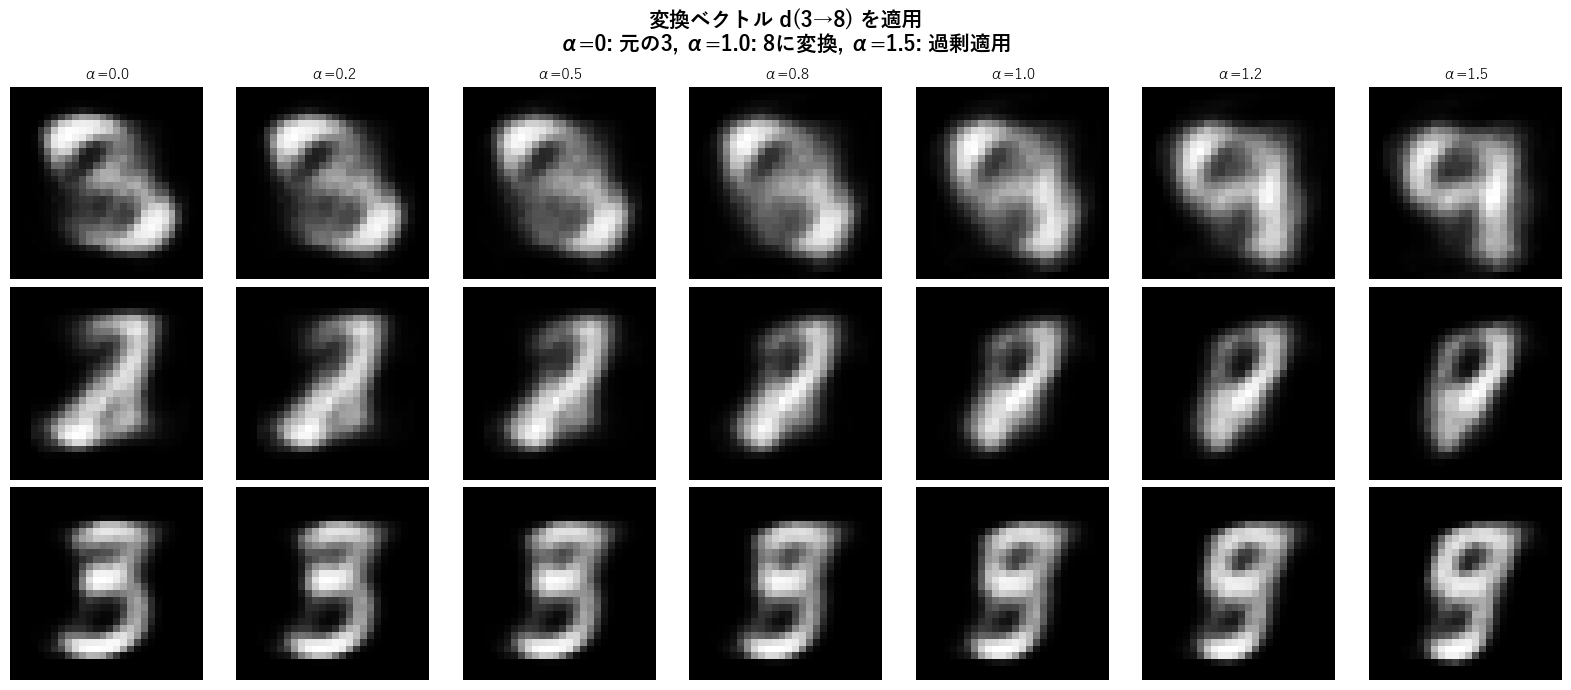

💡 α=0 → 元の3
   α=1.0 → 8に変換（平均的な変換量）
   α=1.5 → 過剰適用（8を超えた生成）


In [4]:
# ============================================================
# 数字間の変換ベクトルの計算と可視化
# ============================================================

def decode_z(z_vec):
    """潜在ベクトルから画像を生成"""
    with torch.no_grad():
        z_tensor = torch.tensor(z_vec, dtype=torch.float32).unsqueeze(0).to(device)
        return model.decode(z_tensor).cpu().numpy().reshape(28, 28)

# 変換ベクトルの計算: 3 → 8
d_3to8 = digit_z_mean[8] - digit_z_mean[3]

# 複数の「3」に変換ベクトルを適用
fig, axes = plt.subplots(3, 7, figsize=(16, 7))

n_samples = 7
alphas = np.linspace(0, 1.5, n_samples)  # 1.0を超えて過剰適用も試す

for row in range(3):
    # ランダムな「3」を選択
    idx = digit_indices[3][row * 5]
    z_source = all_z[idx]

    for col, alpha in enumerate(alphas):
        z_modified = z_source + alpha * d_3to8
        img = decode_z(z_modified)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'α={alpha:.1f}', fontsize=11)

    axes[row, 0].set_ylabel(f'サンプル{row+1}', fontsize=12, rotation=0, labelpad=50)

fig.suptitle('変換ベクトル d(3→8) を適用\nα=0: 元の3, α=1.0: 8に変換, α=1.5: 過剰適用',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_302_01_transform_vector.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 α=0 → 元の3")
print("   α=1.0 → 8に変換（平均的な変換量）")
print("   α=1.5 → 過剰適用（8を超えた生成）")

---

## 3. ベクトル演算: A - B + C = ?

Word2Vecの `king - man + woman = queen` のように、
画像でも `数字A - 数字B + 数字C = ?` を試してみましょう。

$$\vec{z}_{\text{result}} = \vec{z}_A - \vec{z}_B + \vec{z}_C$$

これは「AからBの特性を引き、Cの特性を足す」操作です。

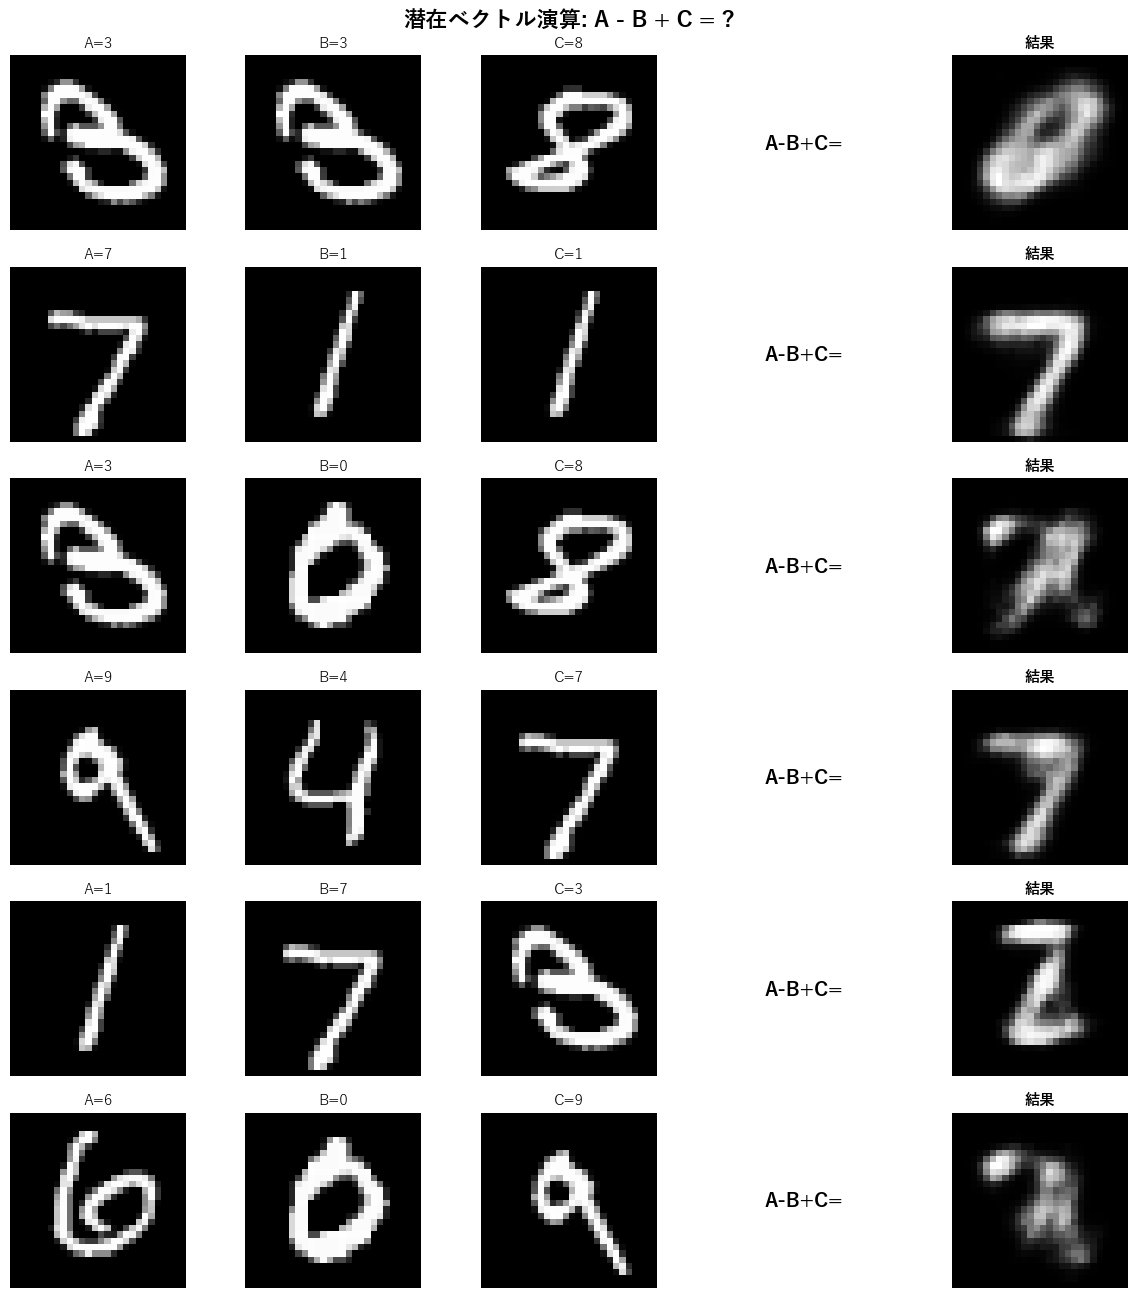

💡 ベクトル演算の直感:
   A - B = 「AにあってBにないもの」（差分ベクトル）
   (A - B) + C = 「Cにその差分を足す」


In [5]:
# ============================================================
# ベクトル演算: A - B + C = ?
# ============================================================

# いくつかの組み合わせを試す
# (A, B, C) → A - B + C = ?
operations = [
    (3, 3, 8, "3 - 3 + 8 = 8?（自明な場合）"),
    (7, 1, 1, "7 - 1 + 1 = 7?（自明な場合）"),
    (3, 0, 8, "3の構造 - 0の丸み + 8の構造 = ?"),
    (9, 4, 7, "9 - 4 + 7 = ?（上部の構造の入替）"),
    (1, 7, 3, "1 - 7 + 3 = ?"),
    (6, 0, 9, "6 - 0 + 9 = ?（向きの反転？）"),
]

fig, axes = plt.subplots(len(operations), 5, figsize=(12, len(operations) * 2.2))

for row, (a, b, c, desc) in enumerate(operations):
    # 各数字のサンプルを使用
    idx_a = digit_indices[a][0]
    idx_b = digit_indices[b][0]
    idx_c = digit_indices[c][0]

    z_a = all_z[idx_a]
    z_b = all_z[idx_b]
    z_c = all_z[idx_c]

    # A - B + C
    z_result = z_a - z_b + z_c

    # 元画像を表示
    imgs = [
        all_images[idx_a].reshape(28, 28),
        all_images[idx_b].reshape(28, 28),
        all_images[idx_c].reshape(28, 28),
    ]
    labels = [f'A={a}', f'B={b}', f'C={c}']

    for col in range(3):
        axes[row, col].imshow(imgs[col], cmap='gray')
        axes[row, col].set_title(labels[col], fontsize=11)
        axes[row, col].axis('off')

    # 演算記号
    axes[row, 3].text(0.5, 0.5, 'A-B+C=', ha='center', va='center',
                     fontsize=14, fontweight='bold', transform=axes[row, 3].transAxes)
    axes[row, 3].axis('off')

    # 結果
    axes[row, 4].imshow(decode_z(z_result), cmap='gray')
    axes[row, 4].set_title('結果', fontsize=11, fontweight='bold')
    axes[row, 4].axis('off')

    # 行ラベル
    axes[row, 0].set_ylabel(desc, fontsize=9, rotation=0, labelpad=120, va='center')

fig.suptitle('潜在ベクトル演算: A - B + C = ?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_302_02_vector_arithmetic.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 ベクトル演算の直感:")
print("   A - B = 「AにあってBにないもの」（差分ベクトル）")
print("   (A - B) + C = 「Cにその差分を足す」")

---

## 4. 属性ベクトルの発見と応用

個別のサンプルではなく、**グループ平均**を使うとより安定した属性ベクトルが得られます。

MNISTでは「太い/細い」「傾いている/まっすぐ」などの属性を発見できます。
ここでは、画像のピクセル密度（インク量）を使って「太さ」の属性ベクトルを構築します。

In [6]:
# ============================================================
# 「太さ」属性ベクトルの発見
# ピクセル値の合計（インク量）で太い/細いを分類
# ============================================================

# 各画像のインク量を計算
ink_amounts = all_images.reshape(len(all_images), -1).sum(axis=1)

# 数字ごとに太い/細いグループを作成
thick_z_list = []
thin_z_list = []

for digit in range(10):
    idx = digit_indices[digit]
    digit_ink = ink_amounts[idx]
    median_ink = np.median(digit_ink)

    thick_mask = digit_ink > np.percentile(digit_ink, 75)
    thin_mask = digit_ink < np.percentile(digit_ink, 25)

    thick_z_list.append(all_z[idx[thick_mask]])
    thin_z_list.append(all_z[idx[thin_mask]])

thick_z_all = np.concatenate(thick_z_list)
thin_z_all = np.concatenate(thin_z_list)

# 属性ベクトル = 太いグループの平均 - 細いグループの平均
thickness_vector = thick_z_all.mean(axis=0) - thin_z_all.mean(axis=0)

print(f"✅ 太さベクトルを計算しました")
print(f"   太いサンプル数: {len(thick_z_all)}")
print(f"   細いサンプル数: {len(thin_z_all)}")
print(f"   ベクトルのノルム: {np.linalg.norm(thickness_vector):.3f}")

✅ 太さベクトルを計算しました
   太いサンプル数: 2502
   細いサンプル数: 2502
   ベクトルのノルム: 1.689


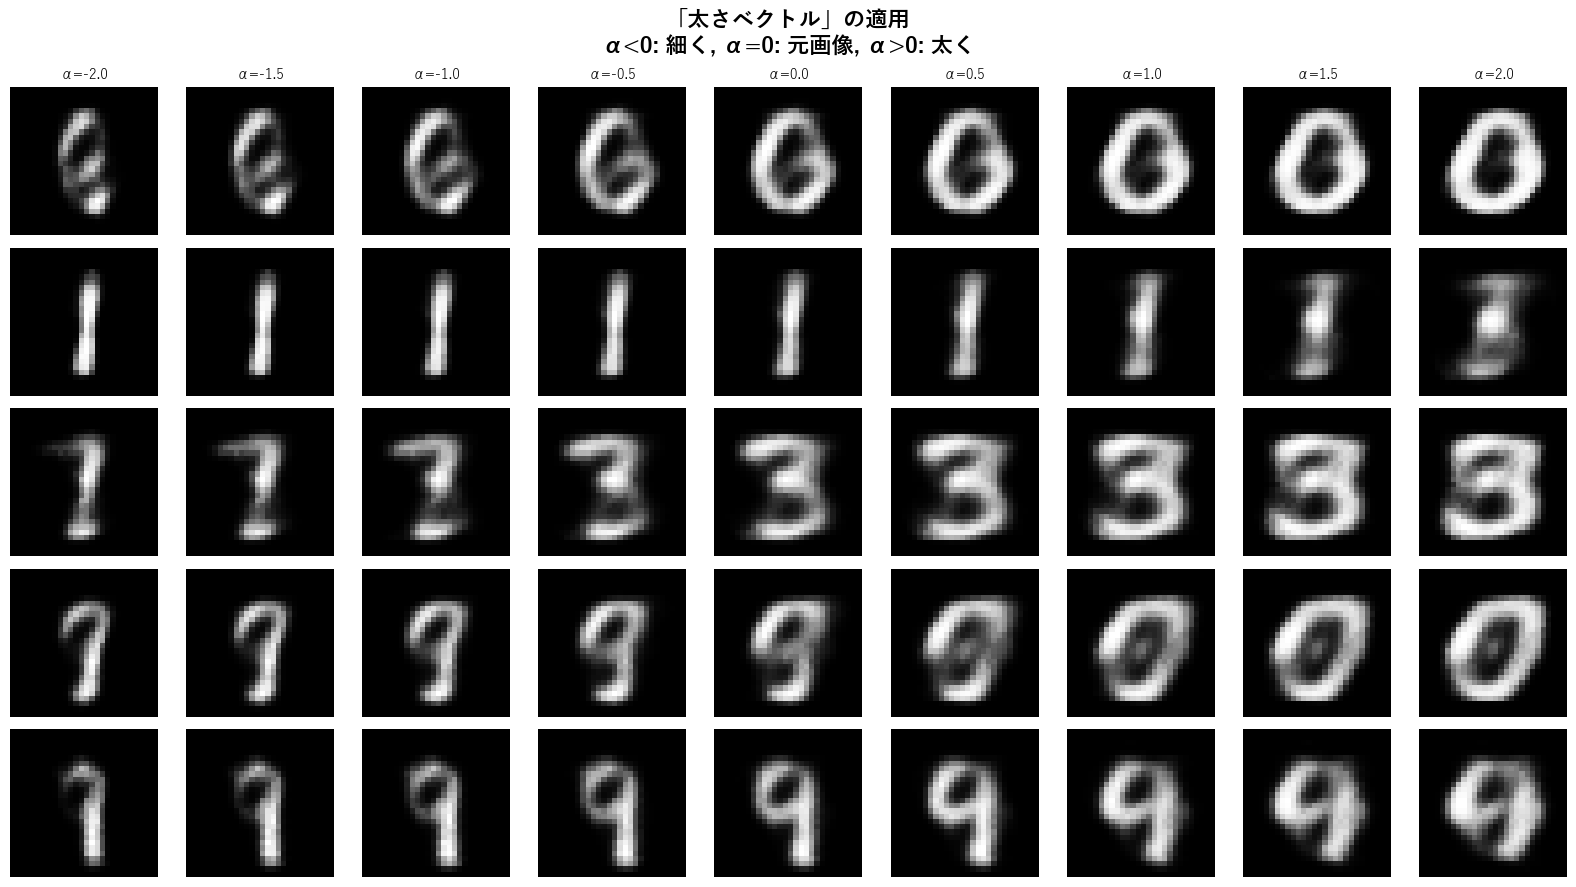

💡 同じ「太さベクトル」が異なる数字に一貫して作用する
   → 属性ベクトルはクラス（数字の種類）に依存しない「汎用的な方向」


In [7]:
# ============================================================
# 太さベクトルを様々な数字に適用
# ============================================================

fig, axes = plt.subplots(5, 9, figsize=(16, 9))

digits_to_show = [0, 1, 3, 5, 7]
alphas = np.linspace(-2, 2, 9)

for row, digit in enumerate(digits_to_show):
    # この数字の中央的なサンプルを選択
    idx = digit_indices[digit]
    # インク量が中央値に近いサンプル
    digit_ink = ink_amounts[idx]
    mid_idx = idx[np.argmin(np.abs(digit_ink - np.median(digit_ink)))]
    z_base = all_z[mid_idx]

    for col, alpha in enumerate(alphas):
        z_modified = z_base + alpha * thickness_vector
        img = decode_z(z_modified)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'α={alpha:.1f}', fontsize=10)
    axes[row, 0].set_ylabel(f'{digit}', fontsize=14, rotation=0, labelpad=20)

fig.suptitle('「太さベクトル」の適用\nα<0: 細く, α=0: 元画像, α>0: 太く',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_302_03_thickness_vector.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 同じ「太さベクトル」が異なる数字に一貫して作用する")
print("   → 属性ベクトルはクラス（数字の種類）に依存しない「汎用的な方向」")

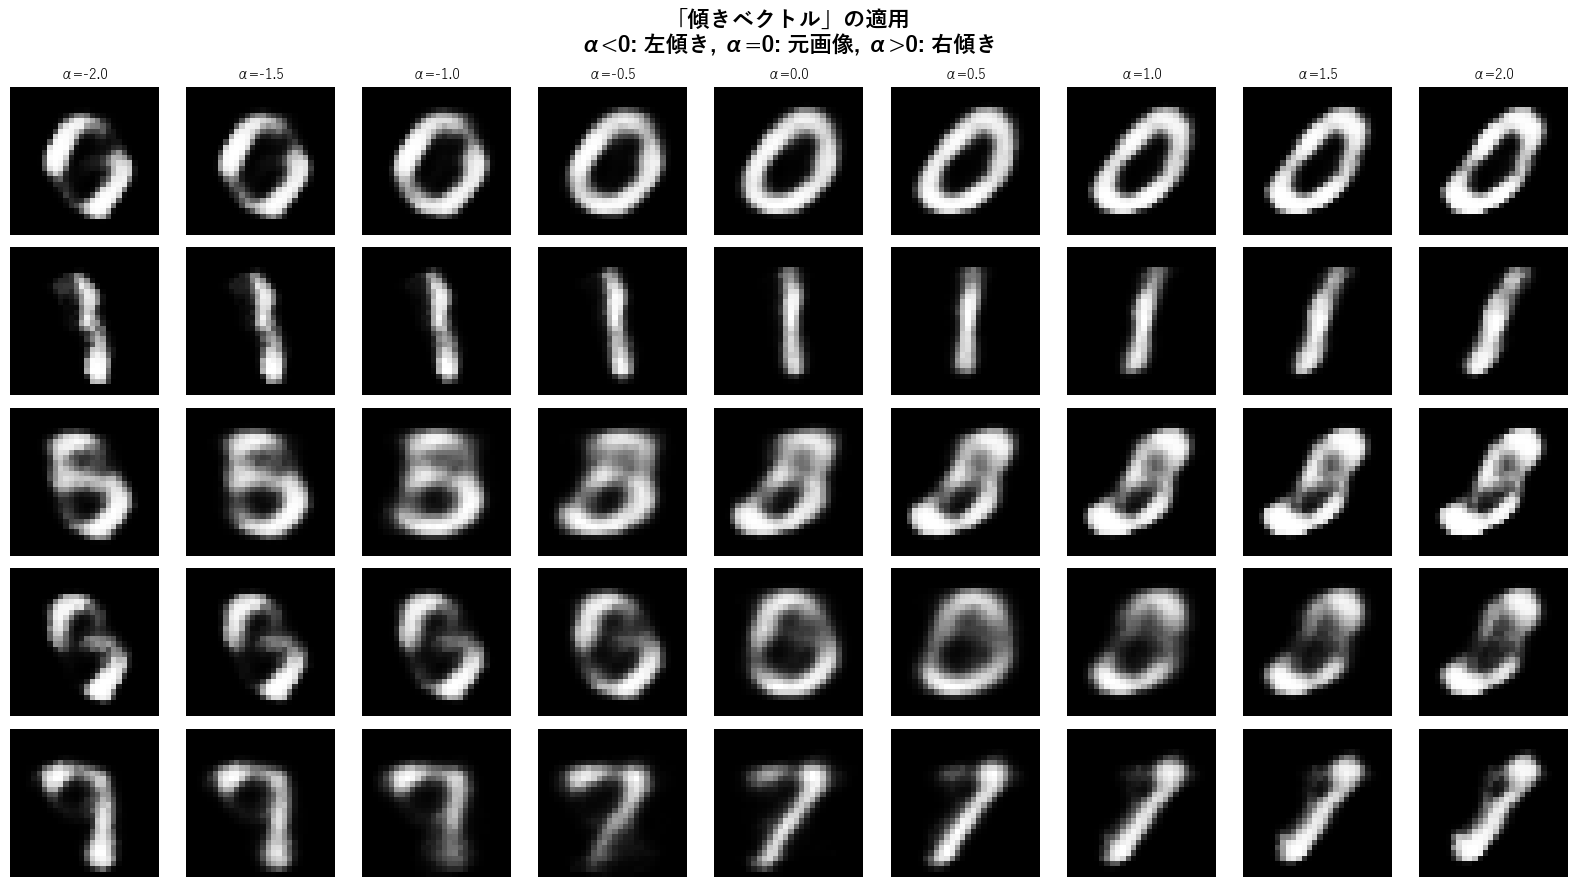

💡 太さとは独立した「傾き」属性も発見可能
   → 複数の属性を同時に操作することもできる！


In [8]:
# ============================================================
# 「傾き」属性ベクトルの発見
# 画像の重心のx座標で左傾き/右傾きを分類
# ============================================================

def compute_slant(image):
    """画像の重心x座標を計算"""
    img = image.reshape(28, 28)
    y_coords, x_coords = np.where(img > 0.3)
    if len(x_coords) == 0:
        return 14.0
    # 上半分の重心と下半分の重心の差で傾きを推定
    upper_mask = y_coords < 14
    lower_mask = y_coords >= 14
    if upper_mask.sum() == 0 or lower_mask.sum() == 0:
        return 0.0
    upper_x = np.average(x_coords[upper_mask], weights=img[y_coords[upper_mask], x_coords[upper_mask]])
    lower_x = np.average(x_coords[lower_mask], weights=img[y_coords[lower_mask], x_coords[lower_mask]])
    return upper_x - lower_x  # 正=右傾き、負=左傾き

# 各画像の傾き計算
slants = np.array([compute_slant(img) for img in all_images.reshape(-1, 784)])

# 右傾き/左傾きグループ
right_mask = slants > np.percentile(slants, 75)
left_mask = slants < np.percentile(slants, 25)

slant_vector = all_z[right_mask].mean(axis=0) - all_z[left_mask].mean(axis=0)

# 傾きベクトルを適用
fig, axes = plt.subplots(5, 9, figsize=(16, 9))
alphas = np.linspace(-2, 2, 9)

for row, digit in enumerate(digits_to_show):
    idx = digit_indices[digit]
    mid_idx = idx[len(idx)//2]
    z_base = all_z[mid_idx]

    for col, alpha in enumerate(alphas):
        z_modified = z_base + alpha * slant_vector
        img = decode_z(z_modified)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'α={alpha:.1f}', fontsize=10)
    axes[row, 0].set_ylabel(f'{digit}', fontsize=14, rotation=0, labelpad=20)

fig.suptitle('「傾きベクトル」の適用\nα<0: 左傾き, α=0: 元画像, α>0: 右傾き',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_302_04_slant_vector.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 太さとは独立した「傾き」属性も発見可能")
print("   → 複数の属性を同時に操作することもできる！")

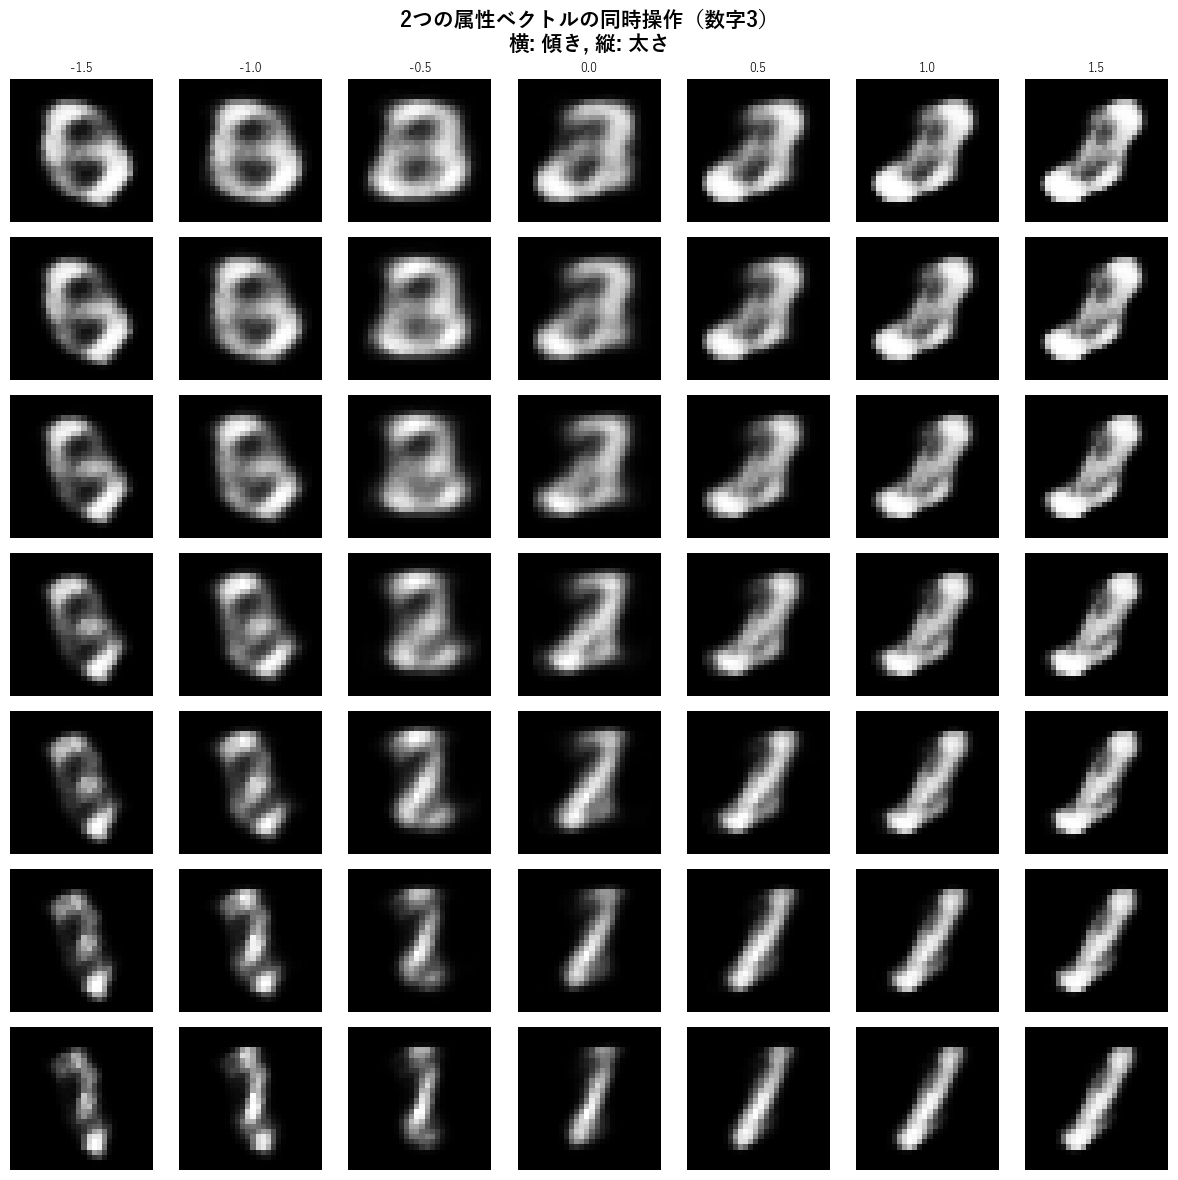

💡 2つの属性ベクトルは（理想的には）独立に操作可能
   → 後のDisentanglement（304章）でこの性質を深掘りします


In [9]:
# ============================================================
# 複数属性の同時操作
# 太さと傾きを同時に変化させるグリッド
# ============================================================

fig, axes = plt.subplots(7, 7, figsize=(12, 12))

digit = 3
idx = digit_indices[digit][5]
z_base = all_z[idx]

thickness_alphas = np.linspace(-1.5, 1.5, 7)
slant_alphas = np.linspace(-1.5, 1.5, 7)

for i, t_alpha in enumerate(reversed(thickness_alphas)):
    for j, s_alpha in enumerate(slant_alphas):
        z_mod = z_base + t_alpha * thickness_vector + s_alpha * slant_vector
        img = decode_z(z_mod)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f'{s_alpha:.1f}', fontsize=9)
        if j == 0:
            axes[i, j].set_ylabel(f'{t_alpha:.1f}', fontsize=9, rotation=0, labelpad=20)

fig.suptitle('2つの属性ベクトルの同時操作（数字3）\n横: 傾き, 縦: 太さ',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_302_05_dual_attribute.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 2つの属性ベクトルは（理想的には）独立に操作可能")
print("   → 後のDisentanglement（304章）でこの性質を深掘りします")

---

## まとめ

### 🎯 このノートブックで学んだこと

**ベクトル演算の基本**
- ✓ 変換ベクトル d = z_B - z_A で「AからBへの方向」を表現
- ✓ A - B + C の演算で、属性の入替えが可能

**属性ベクトルの発見**
- ✓ グループ平均の差として属性ベクトルを計算
- ✓ 太さ、傾きなど、意味のある属性を発見できる
- ✓ 属性ベクトルは異なるクラスにも汎用的に適用可能

**複数属性の操作**
- ✓ 複数の属性ベクトルを同時に足すことで、独立に操作可能

### ⚠️ よくある間違い

❌ 「属性ベクトルは常に正確に機能する」
✅ VAEの潜在空間は完全にdisentangleされていないため、1つの属性を変えると他も影響を受けることがある

❌ 「個々のサンプル対の差分=属性ベクトル」
✅ 個別サンプルはノイズが多い。グループ平均を使うとより安定した高品質な属性ベクトルが得られる

### ✅ 学習チェックリスト

- [ ] 変換ベクトルの計算方法を説明できるか？
- [ ] なぜグループ平均が個別サンプルより良いか説明できるか？
- [ ] 2つの属性を同時に操作できる条件は何か？

---

**次のステップ**: ノートブック303「潜在走査」で、潜在空間の各次元を1つずつ動かし、各次元がどんな意味を持つかを発見します！

---

## 🎓 自己評価クイズ

### Q1: 属性ベクトルを計算する際、なぜ単一サンプルの差ではなくグループ平均の差を使うべきか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 単一サンプルにはその属性以外のノイズ（個体差）が含まれるため

例えば、太い3と細い3の差には、太さだけでなくその特定の3の書き方の癖も含まれます。
多数のサンプルを平均すると、個体差が打ち消し合い、純粋な属性方向だけが残ります。

</details>

---

### Q2: A - B + C = ? の演算は、直感的に何を意味するか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 「AにあってBにない特徴」を「C」に加える操作

d = A - B は「AとBの差分」。これをCに足すことで、BからAへの変化をCにも適用します。
Word2Vecの king - man + woman = queen と同じ原理です。

</details>

---

### Q3: 太さベクトルを強度α=5.0で適用したらどうなるか？

<details>
<summary>💡 答えを見る</summary>

**答え**: データの分布から大きく外れ、意味のない（崩れた）画像が生成される

VAEの潜在空間は学習データの近傍でのみ意味のある構造を持ちます。
過度な強度は「データが存在しない領域」に到達してしまい、デコーダは対応できません。
α=1〜2程度が実用的な範囲です。

</details>